## LCA Dataset - Random Forest Regression Analysis

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 1. Data Loading and Exploration

In [ ]:
# Load the dataset
df = pd.read_csv('lca_data.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (54, 14)

Column Names:
['Bottle Material type', 'Filled material', 'Cap material', 'Label', 'Mass (kg)', 'No of uses', 'Transport mode', 'Transport distance (km)', 'Manufacturing process', 'EOL _scenerio', 'EOL (%)', 'Electricity mix', 'Electricity value (kWh)', 'GWP (kg CO2 eq)']

First 5 rows:


,Bottle Material type,Filled material,Cap material,Label,Mass (kg),No of uses,Transport mode,Transport distance (km),Manufacturing process,EOL _scenerio,EOL (%),Electricity mix,Electricity value (kWh),GWP (kg CO2 eq)
0,PLA,no,no,no,0.0228,1.0,no,0,Raw material acquisition,no,0.0,"Medium voltage, Poland",0.000368,0.0040
1,PLA,no,no,no,0.0228,1.0,no,0,Preform heating,no,0.0,"Medium voltage, Poland",0.009760,0.0054
2,PLA,no,no,no,0.0228,1.0,no,0,Streching and extending,no,0.0,"Medium voltage, Poland",0.006950,0.0064
3,PLA,no,no,no,0.0228,1.0,no,0,Pressure shaping,no,0.0,"Medium voltage, Poland",0.005660,0.0073
4,PLA,no,no,no,0.0228,1.0,no,0,Bottle degasifying,no,0.0,"Medium voltage, Poland",0.001010,0.0074


In [ ]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Types:
Bottle Material type           str
Filled material                str
Cap material                   str
Label                          str
Mass (kg)                  float64
No of uses                 float64
Transport mode                 str
Transport distance (km)      int64
Manufacturing process          str
EOL _scenerio                  str
EOL (%)                    float64
Electricity mix                str
Electricity value (kWh)    float64
GWP (kg CO2 eq)            float64
dtype: object

Missing Values:
Bottle Material type       0
Filled material            0
Cap material               0
Label                      0
Mass (kg)                  0
No of uses                 0
Transport mode             0
Transport distance (km)    0
Manufacturing process      0
EOL _scenerio              0
EOL (%)                    0
Electricity mix            0
Electricity value (kWh)    0
GWP (kg CO2 eq)            0
dtype: int64

Basic Statistics:


,Mass (kg),No of uses,Transport distance (km),EOL (%),Electricity value (kWh),GWP (kg CO2 eq)
count,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,0.213737,2.083333,45.962963,11.507407,0.148042,12.157240
std,0.189823,2.295915,119.675184,26.371038,0.151093,32.553927
min,0.010000,1.000000,0.000000,0.000000,0.000368,-24.300000
25%,0.022800,1.000000,0.000000,0.000000,0.148000,0.006625
50%,0.225000,1.000000,0.000000,0.000000,0.148000,0.055000
75%,0.450000,1.000000,37.500000,0.000000,0.148000,1.047500
max,0.450000,7.000000,600.000000,100.000000,1.012100,122.600000


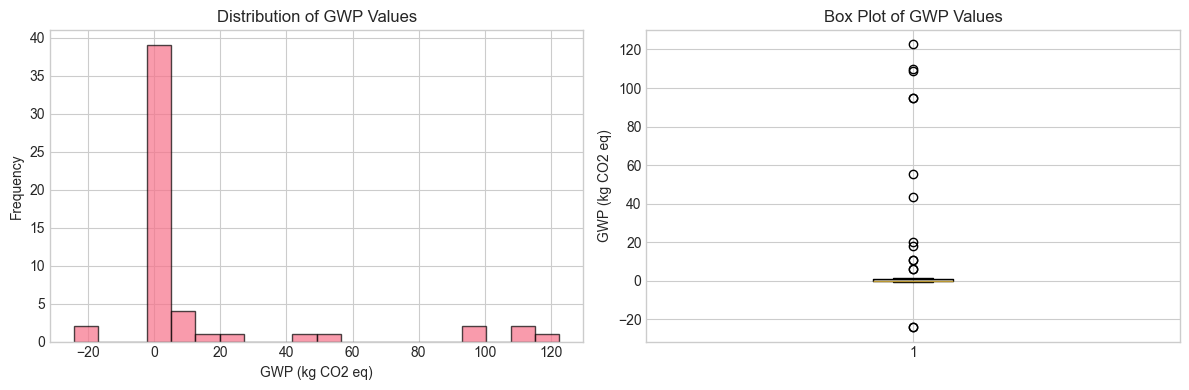


GWP Range: -24.3000 to 122.6000


In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['GWP (kg CO2 eq)'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GWP (kg CO2 eq)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of GWP Values')

# Box plot
axes[1].boxplot(df['GWP (kg CO2 eq)'])
axes[1].set_ylabel('GWP (kg CO2 eq)')
axes[1].set_title('Box Plot of GWP Values')

plt.tight_layout()
plt.show()

print(f"\nGWP Range: {df['GWP (kg CO2 eq)'].min():.4f} to {df['GWP (kg CO2 eq)'].max():.4f}")

## 2. Data Preprocessing

We need to encode categorical features for the Random Forest model.

In [ ]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from numerical columns
target_col = 'GWP (kg CO2 eq)'
numerical_cols.remove(target_col)

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)
print("\nTarget column:", target_col)

Categorical columns: ['Bottle Material type', 'Filled material', 'Cap material', 'Label', 'Transport mode', 'Manufacturing process', 'EOL _scenerio', 'Electricity mix']

Numerical columns: ['Mass (kg)', 'No of uses', 'Transport distance (km)', 'EOL (%)', 'Electricity value (kWh)']

Target column: GWP (kg CO2 eq)


/var/folders/6p/zr10187d4g13x813355_6x0r0000gn/T/ipykernel_546/3000988245.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [ ]:
# Check unique values in categorical columns
print("Unique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())

Unique values in categorical columns:

Bottle Material type:
<StringArray>
['PLA', 'Amber glass', 'Glass', 'PET', 'Bio-based PET', 'glass']
Length: 6, dtype: str

Filled material:
<StringArray>
['no', 'Water', 'Sparkling Water']
Length: 3, dtype: str

Cap material:
<StringArray>
['no', 'Aluminium', 'Alminium', 'HDPE']
Length: 4, dtype: str

Label:
<StringArray>
['no', 'Paper', 'PE']
Length: 3, dtype: str

Transport mode:
<StringArray>
['no', 'Truck']
Length: 2, dtype: str

Manufacturing process:
<StringArray>
[   'Raw material acquisition',             'Preform heating',
     'Streching and extending',            'Pressure shaping',
          'Bottle degasifying',              'Bottle cooling',
                         'CTG',        'Packaging production',
      'Bottle plant operation',                'Distribution',
                         'EOL',       'LUC (land use change)',
             'Biogenic carbon',          'EU crop production',
          'Ethanol production',      'Ethano

In [ ]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nProcessed DataFrame shape:", df_processed.shape)
df_processed.head()

Bottle Material type: {'Amber glass': 0, 'Bio-based PET': 1, 'Glass': 2, 'PET': 3, 'PLA': 4, 'glass': 5}
Filled material: {'Sparkling Water': 0, 'Water': 1, 'no': 2}
Cap material: {'Alminium': 0, 'Aluminium': 1, 'HDPE': 2, 'no': 3}
Label: {'PE': 0, 'Paper': 1, 'no': 2}
Transport mode: {'Truck': 0, 'no': 1}
Manufacturing process: {'Bio-MEG production': 0, 'Bio-MEG transportation': 1, 'Biogenic carbon': 2, 'Bottle cooling': 3, 'Bottle degasifying': 4, 'Bottle plant operation': 5, 'CTG': 6, 'Distribution': 7, 'EOL': 8, 'EU crop production': 9, 'Ethanol production': 10, 'Ethanol transportation': 11, 'LUC (land use change)': 12, 'Moulding': 13, 'PTA production': 14, 'Packaging production': 15, 'Polymerization': 16, 'Preform heating': 17, 'Pressure shaping': 18, 'Raw material acquisition': 19, 'Streching and extending': 20, 'bottle forming': 21, 'drying': 22, 'glass melting and handling': 23, 'input glass': 24, 'packaging': 25, 'shredding': 26, 'sterilization': 27, 'transport to glass produc

,Bottle Material type,Filled material,Cap material,Label,Mass (kg),No of uses,Transport mode,Transport distance (km),Manufacturing process,EOL _scenerio,EOL (%),Electricity mix,Electricity value (kWh),GWP (kg CO2 eq)
0,4,2,3,2,0.0228,1.0,1,0,19,5,0.0,2,0.000368,0.0040
1,4,2,3,2,0.0228,1.0,1,0,17,5,0.0,2,0.009760,0.0054
2,4,2,3,2,0.0228,1.0,1,0,20,5,0.0,2,0.006950,0.0064
3,4,2,3,2,0.0228,1.0,1,0,18,5,0.0,2,0.005660,0.0073
4,4,2,3,2,0.0228,1.0,1,0,4,5,0.0,2,0.001010,0.0074


In [ ]:
# Separate features (X) and target (y)
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (54, 13)
Target shape: (54,)

Feature columns:
['Bottle Material type', 'Filled material', 'Cap material', 'Label', 'Mass (kg)', 'No of uses', 'Transport mode', 'Transport distance (km)', 'Manufacturing process', 'EOL _scenerio', 'EOL (%)', 'Electricity mix', 'Electricity value (kWh)']


## 3. Model Training

In [ ]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 43
Test set size: 11


In [ ]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")

Model trained successfully!
Number of trees: 100
Max depth: 10


In [ ]:
# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

## 4. Model Evaluation

Evaluating model performance using R², RMSE, and MAE metrics.

In [ ]:
# Calculate evaluation metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and display regression metrics."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{'='*40}")
    print(f"{dataset_name} Metrics:")
    print(f"{'='*40}")
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print(f"MAE:       {mae:.4f}")

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

# Training metrics
train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")

# Test metrics
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")


Training Set Metrics:
R² Score:  0.8665
RMSE:      10.9632
MAE:       4.4026

Test Set Metrics:
R² Score:  0.6079
RMSE:      24.2422
MAE:       11.5107


In [ ]:
# Create metrics comparison table
metrics_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Training': [train_metrics['R2'], train_metrics['RMSE'], train_metrics['MAE']],
    'Test': [test_metrics['R2'], test_metrics['RMSE'], test_metrics['MAE']]
})
metrics_df = metrics_df.round(4)
print("\nMetrics Comparison Table:")
metrics_df


Metrics Comparison Table:


,Metric,Training,Test
0,R² Score,0.8665,0.6079
1,RMSE,10.9632,24.2422
2,MAE,4.4026,11.5107


## 5. Visualizations

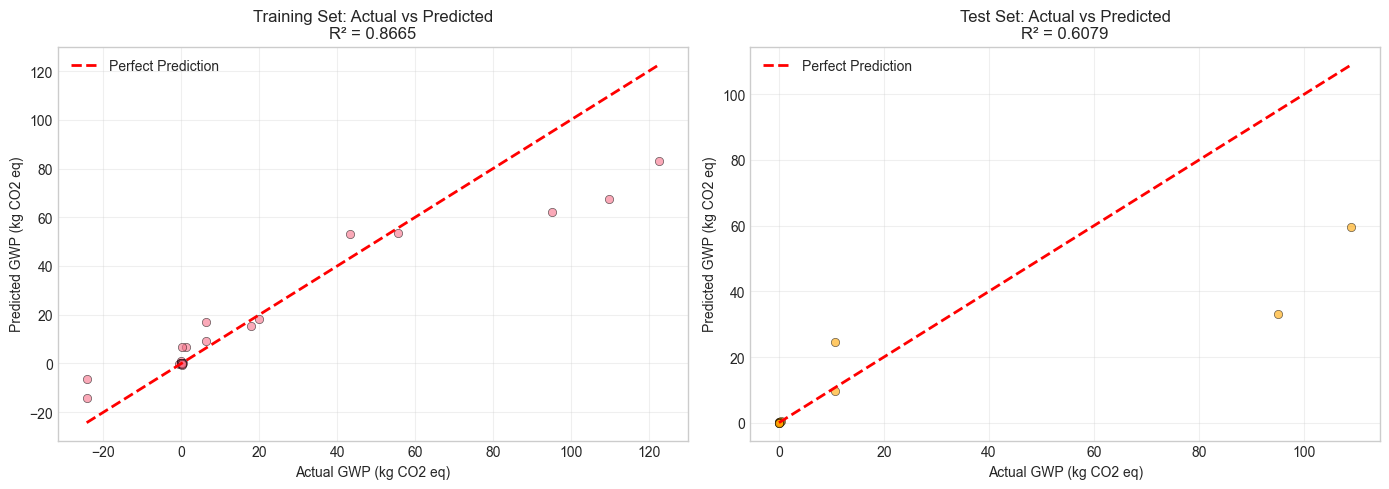

In [ ]:
# Actual vs Predicted Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual GWP (kg CO2 eq)')
axes[0].set_ylabel('Predicted GWP (kg CO2 eq)')
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["R2"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual GWP (kg CO2 eq)')
axes[1].set_ylabel('Predicted GWP (kg CO2 eq)')
axes[1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["R2"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

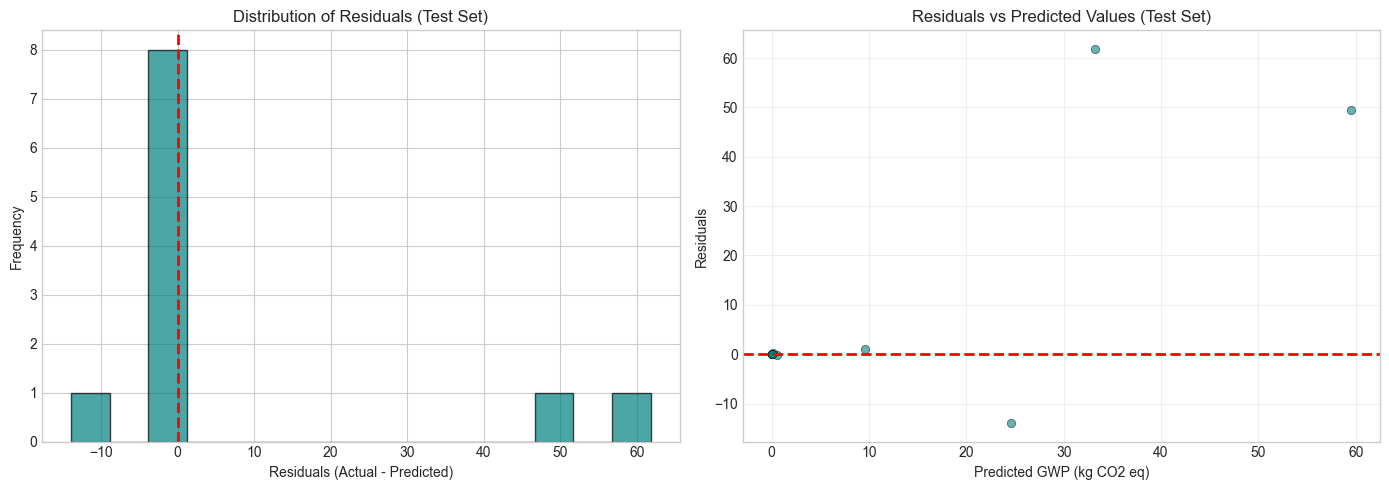

In [ ]:
# Residual Analysis
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals_test, bins=15, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals (Test Set)')

# Residuals vs Predicted
axes[1].scatter(y_test_pred, residuals_test, alpha=0.6, edgecolors='black', linewidth=0.5, color='teal')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted GWP (kg CO2 eq)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values (Test Set)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

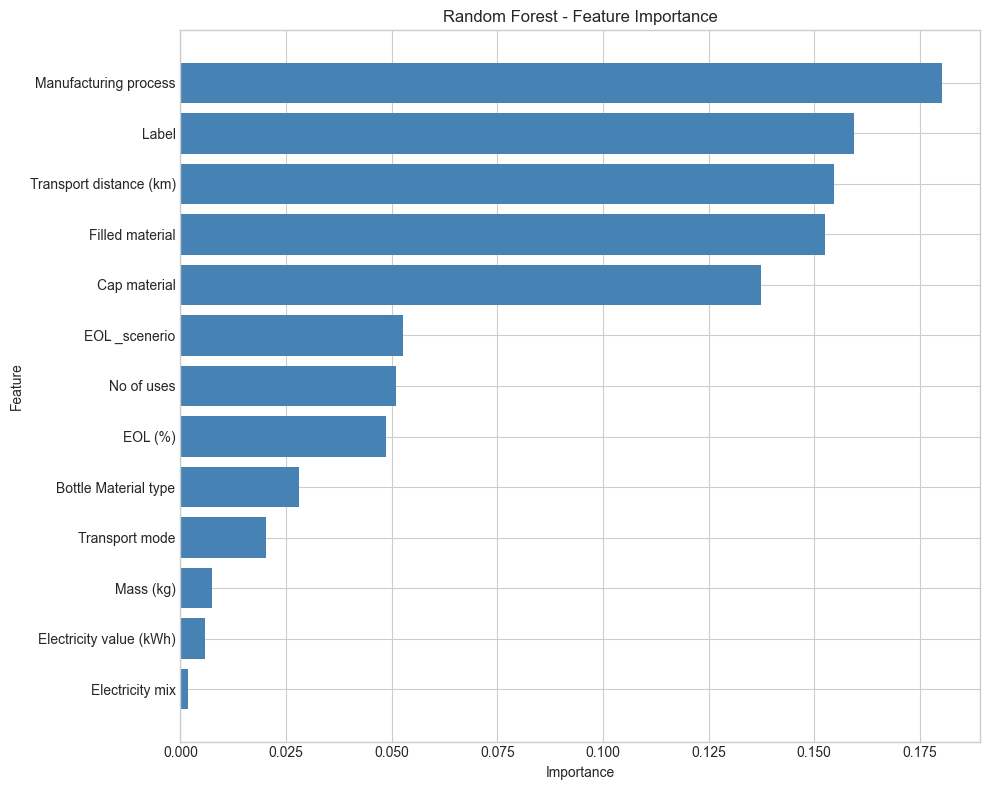


Top 5 Most Important Features:


,Feature,Importance
8,Manufacturing process,0.180241
3,Label,0.159422
7,Transport distance (km),0.154701
1,Filled material,0.152460
2,Cap material,0.137416


In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
feature_importance.sort_values('Importance', ascending=False).head()

## Summary

This notebook performed the following:
1. **Loaded** the LCA dataset with 54 samples and 14 features
2. **Preprocessed** the data by encoding 8 categorical columns using LabelEncoder
3. **Trained** a Random Forest Regressor with 100 trees
4. **Evaluated** the model using R², RMSE, and MAE metrics
5. **Visualized** results with actual vs predicted plots, residual analysis, and feature importance

In [ ]:
# Final Summary Output
print("="*50)
print("RANDOM FOREST REGRESSION - FINAL RESULTS")
print("="*50)
print(f"\nDataset: {len(df)} samples")
print(f"Features: {len(X.columns)} columns")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTest Set Performance:")
print(f"  R² Score: {test_metrics['R2']:.4f}")
print(f"  RMSE:     {test_metrics['RMSE']:.4f} kg CO2 eq")
print(f"  MAE:      {test_metrics['MAE']:.4f} kg CO2 eq")
print("="*50)

RANDOM FOREST REGRESSION - FINAL RESULTS

Dataset: 54 samples
Features: 13 columns
Training samples: 43
Test samples: 11

Test Set Performance:
  R² Score: 0.6079
  RMSE:     24.2422 kg CO2 eq
  MAE:      11.5107 kg CO2 eq
